In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# Pre-processing

In [2]:
files = os.listdir('res/accuracy')
column_names = ['epoch', 'step', 'plain_acc', 'enc_acc']

In [3]:
dfs1 = [pd.read_csv(f'res/accuracy/{file}', header=None, names=column_names).iloc[:400,2:] for file in files]
dfs2 = [pd.read_csv(f'res/accuracy/{file}', header=None, names=column_names).iloc[400:800,2:] for file in files]
dfs3 = [pd.read_csv(f'res/accuracy/{file}', header=None, names=column_names).iloc[800:,2:] for file in files]
dfs3[0]

,plain_acc,enc_acc
800,0.083333,0.083333
801,0.041667,0.041667
802,0.062500,0.062500
803,0.062500,0.062500
804,0.041667,0.041667
...,...,...
1195,0.895833,0.895833
1196,0.833333,0.833333
1197,0.937500,0.937500
1198,0.979167,0.979167


In [4]:
# Stack dataframes along a new axis and compute mean along that axis
mean_df1 = np.mean(dfs1, axis=0)
mean_df1 = pd.DataFrame(mean_df1, columns=column_names[2:])

mean_df2 = np.mean(dfs2, axis=0)
mean_df2 = pd.DataFrame(mean_df2, columns=column_names[2:])

mean_df3 = np.mean(dfs3, axis=0)
mean_df3 = pd.DataFrame(mean_df3, columns=column_names[2:])
mean_df3

,plain_acc,enc_acc
0,0.055556,0.055556
1,0.062500,0.062500
2,0.062500,0.062500
3,0.069444,0.069444
4,0.048611,0.048611
...,...,...
395,0.909722,0.909722
396,0.861111,0.861111
397,0.881944,0.881944
398,0.951389,0.951389


In [5]:
# Stack dataframes along a new axis and compute std along that axis
std_df1 = np.std(dfs1, axis=0)
std_df1 = pd.DataFrame(std_df1, columns=column_names[2:])

std_df2 = np.std(dfs2, axis=0)
std_df2 = pd.DataFrame(std_df2, columns=column_names[2:])

std_df3 = np.std(dfs3, axis=0)
std_df3 = pd.DataFrame(std_df3, columns=column_names[2:])
std_df3

,plain_acc,enc_acc
0,0.019642,0.019642
1,0.017010,0.017010
2,0.017010,0.017010
3,0.009821,0.009821
4,0.025984,0.025984
...,...,...
395,0.019642,0.019642
396,0.019642,0.019642
397,0.064400,0.064400
398,0.025984,0.025984


# Plot

In [6]:
params = {
   'font.size': 26,
   'axes.linewidth': 1.25,
   'axes.labelsize': 30,
   'legend.fontsize': 22,
   'xtick.labelsize': 26,
   'ytick.labelsize': 26,
   'pdf.fonttype': 42,
   'ps.fonttype': 42
}
plt.rcParams.update(params)

In [7]:
x_label = r'Iteration $t$'
y_label = 'Train accuracy %'
legend_labels = ['Plain', 'Encrypted']

In [8]:
from palettable.colorbrewer.qualitative import Set2_3
colors = Set2_3.mpl_colors

### EMLP-1

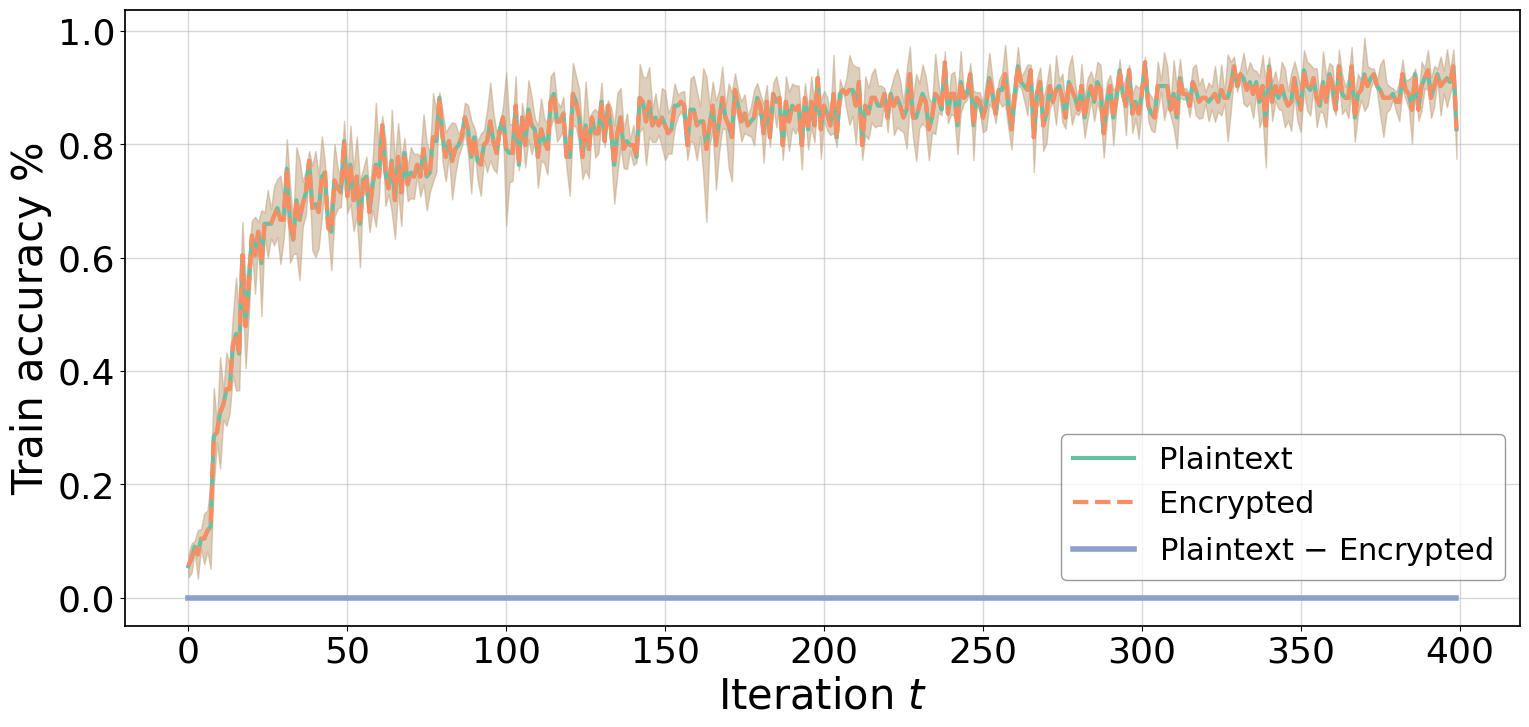

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(18, 8))
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)

plain_mean = mean_df1['plain_acc']
enc_mean = mean_df1['enc_acc']
plain_std = std_df1['plain_acc']
enc_std = std_df1['enc_acc']

# Plot mean lines with labels for the legend
sns.lineplot(
    x=np.arange(0, len(plain_mean)), y=plain_mean,
    color=colors[0], ax=ax, marker=None,
    linewidth=3, markersize=5, linestyle='-', label="Plaintext"
)
sns.lineplot(
    x=np.arange(0, len(enc_mean)), y=enc_mean,
    color=colors[1], ax=ax, marker=None,
    linewidth=3, markersize=5, linestyle='--', label="Encrypted"
)

# Plot the difference between plain and encrypted (no scaling)
plain_enc_diff = plain_mean - enc_mean
sns.lineplot(
    x=np.arange(0, len(plain_enc_diff)), y=plain_enc_diff,
    color=colors[2], ax=ax, marker=None,
    linewidth=4, markersize=5, linestyle='-', label=r'Plaintext $-$ Encrypted'
)

# Plot standard deviation as shaded areas
ax.fill_between(np.arange(0, len(plain_mean)), plain_mean - plain_std, plain_mean + plain_std, color=colors[0], alpha=0.3)
ax.fill_between(np.arange(0, len(enc_mean)), enc_mean - enc_std, enc_mean + enc_std, color=colors[1], alpha=0.3)

ax.tick_params(axis='x')
ax.tick_params(axis='y')

# Create legend in the lower right outside the plot
legend = ax.legend(loc='lower right', bbox_to_anchor=(1, 0.05), frameon=True)
frame = legend.get_frame()
frame.set_edgecolor('0.5')
ax.grid(linewidth=1, alpha=0.5, axis='both')

In [10]:
from pathlib import Path

fn = Path(f'out/acc_comparison_emlp1.pdf')
fig.savefig(fn, bbox_inches='tight')

### EMLP-2

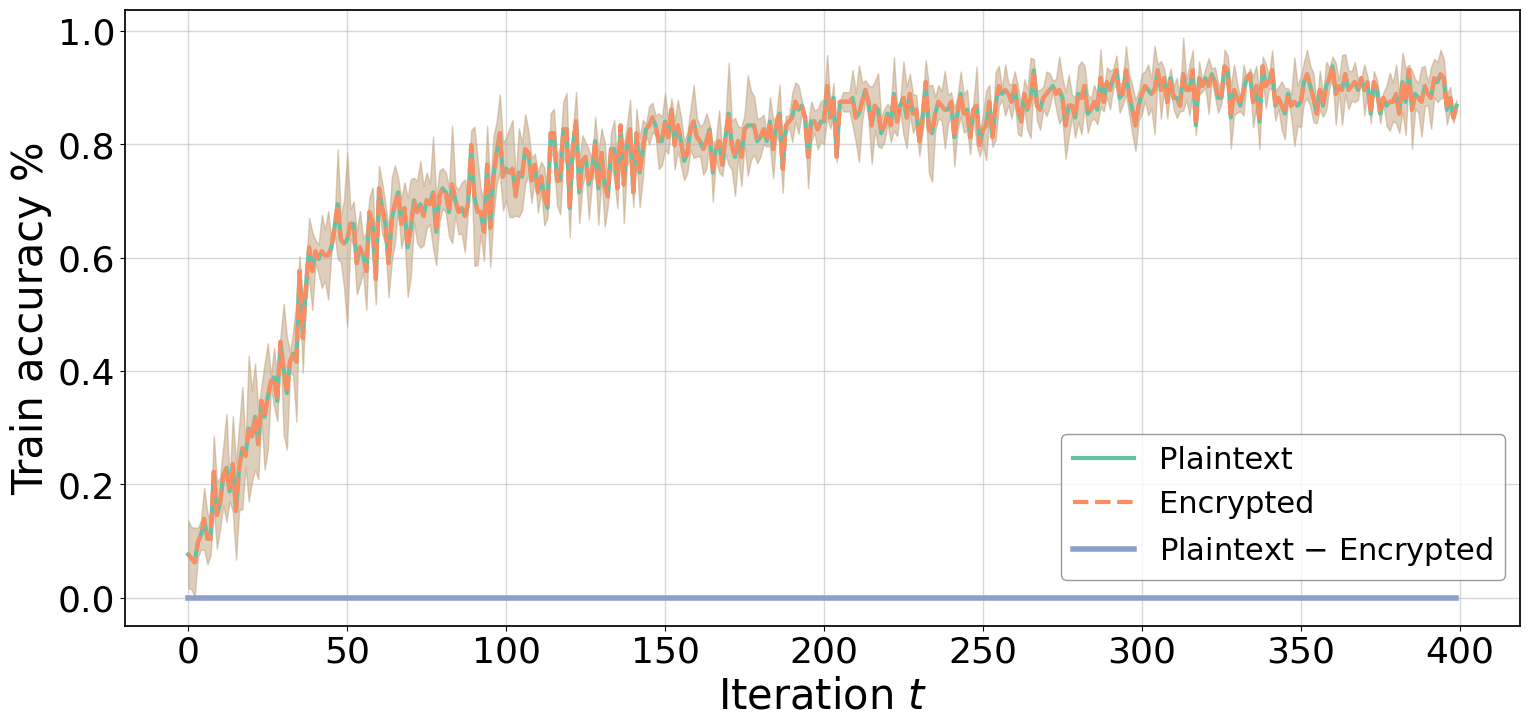

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(18, 8))
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)

plain_mean = mean_df2['plain_acc']
enc_mean = mean_df2['enc_acc']
plain_std = std_df2['plain_acc']
enc_std = std_df2['enc_acc']

# Plot mean lines with labels for the legend
sns.lineplot(
    x=np.arange(0, len(plain_mean)), y=plain_mean,
    color=colors[0], ax=ax, marker=None,
    linewidth=3, markersize=5, linestyle='-', label="Plaintext"
)
sns.lineplot(
    x=np.arange(0, len(enc_mean)), y=enc_mean,
    color=colors[1], ax=ax, marker=None,
    linewidth=3, markersize=5, linestyle='--', label="Encrypted"
)

# Plot the difference between plain and encrypted (no scaling)
plain_enc_diff = plain_mean - enc_mean
sns.lineplot(
    x=np.arange(0, len(plain_enc_diff)), y=plain_enc_diff,
    color=colors[2], ax=ax, marker=None,
    linewidth=4, markersize=5, linestyle='-', label=r'Plaintext $-$ Encrypted'
)

# Plot standard deviation as shaded areas
ax.fill_between(np.arange(0, len(plain_mean)), plain_mean - plain_std, plain_mean + plain_std, color=colors[0], alpha=0.3)
ax.fill_between(np.arange(0, len(enc_mean)), enc_mean - enc_std, enc_mean + enc_std, color=colors[1], alpha=0.3)

ax.tick_params(axis='x')
ax.tick_params(axis='y')

# Create legend in the lower right outside the plot
legend = ax.legend(loc='lower right', bbox_to_anchor=(1, 0.05), frameon=True)
frame = legend.get_frame()
frame.set_edgecolor('0.5')
ax.grid(linewidth=1, alpha=0.5, axis='both')

In [12]:
from pathlib import Path

fn = Path(f'out/acc_comparison_emlp2.pdf')
fig.savefig(fn, bbox_inches='tight')

### EMLP-3

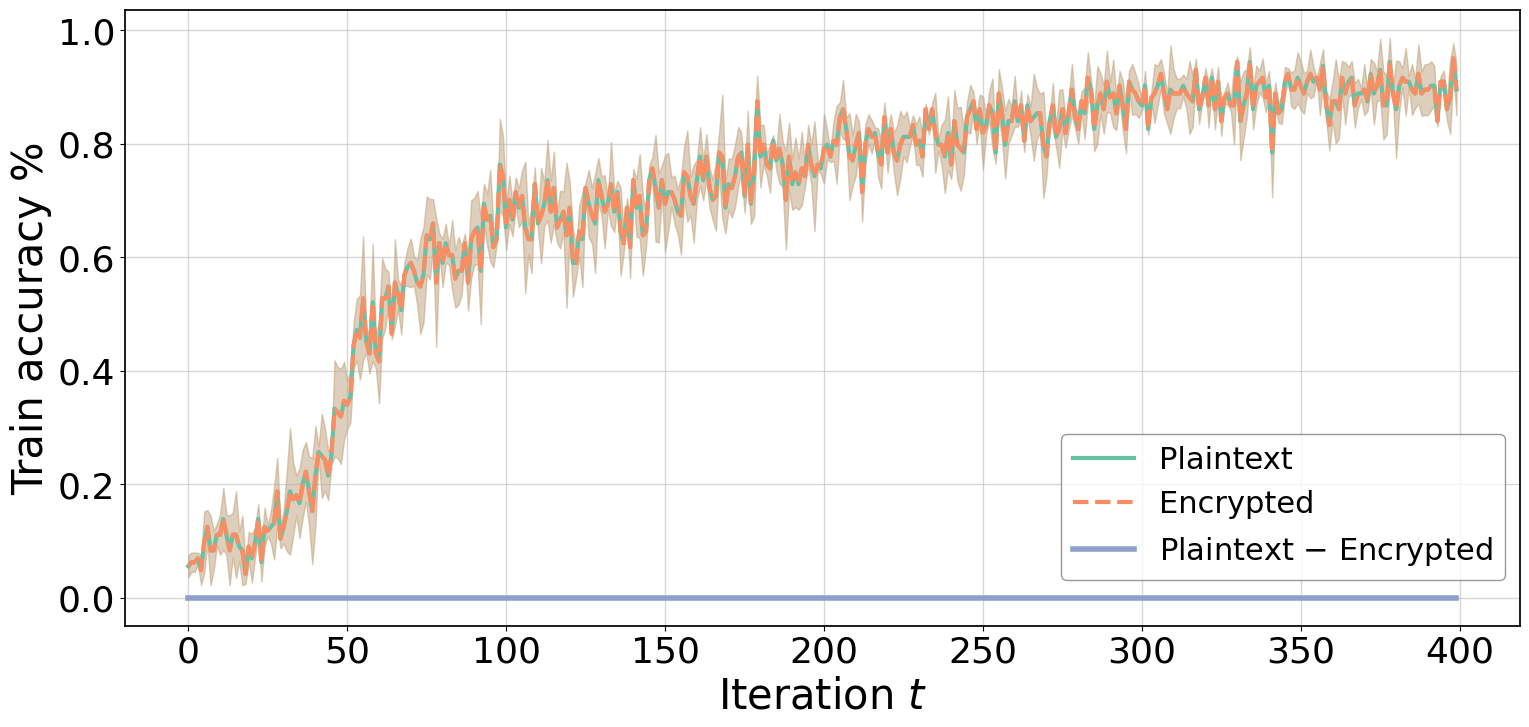

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(18, 8))
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)

plain_mean = mean_df3['plain_acc']
enc_mean = mean_df3['enc_acc']
plain_std = std_df3['plain_acc']
enc_std = std_df3['enc_acc']

# Plot mean lines with labels for the legend
sns.lineplot(
    x=np.arange(0, len(plain_mean)), y=plain_mean,
    color=colors[0], ax=ax, marker=None,
    linewidth=3, markersize=5, linestyle='-', label="Plaintext"
)
sns.lineplot(
    x=np.arange(0, len(enc_mean)), y=enc_mean,
    color=colors[1], ax=ax, marker=None,
    linewidth=3, markersize=5, linestyle='--', label="Encrypted"
)

# Plot the difference between plain and encrypted (no scaling)
plain_enc_diff = plain_mean - enc_mean
sns.lineplot(
    x=np.arange(0, len(plain_enc_diff)), y=plain_enc_diff,
    color=colors[2], ax=ax, marker=None,
    linewidth=4, markersize=5, linestyle='-', label=r'Plaintext $-$ Encrypted'
)

# Plot standard deviation as shaded areas
ax.fill_between(np.arange(0, len(plain_mean)), plain_mean - plain_std, plain_mean + plain_std, color=colors[0], alpha=0.3)
ax.fill_between(np.arange(0, len(enc_mean)), enc_mean - enc_std, enc_mean + enc_std, color=colors[1], alpha=0.3)

ax.tick_params(axis='x')
ax.tick_params(axis='y')

# Create legend in the lower right outside the plot
legend = ax.legend(loc='lower right', bbox_to_anchor=(1, 0.05), frameon=True)
frame = legend.get_frame()
frame.set_edgecolor('0.5')
ax.grid(linewidth=1, alpha=0.5, axis='both')

In [14]:
from pathlib import Path

fn = Path(f'out/acc_comparison_emlp3.pdf')
fig.savefig(fn, bbox_inches='tight')